#### Problem 2: Why Noise Weighting Matters

You measure a signal that should follow a linear relation 

$$
y = ax + b
$$

but each data point has a different uncertainty $\sigma_i$.

You are given arrays ($x_i$, $y_i$, $\sigma_i$).

##### (a) Unweighted fit

Fit the model using ordinary least squares (ignore $\sigma_i). Plot the data and best-fit line. 

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Load data
data = pd.read_csv("/Users/laurensdun/phys657-spring2026/Module3/weighted_regression_dataset.csv")

# Extract columns as arrays
x = data["x"].values
y = data["y"].values
sigma = data["sigma"].values

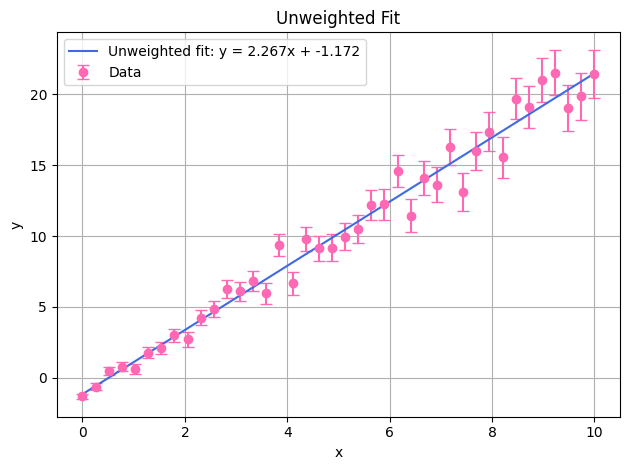

In [13]:
# polynomial of degree 1 with coefficients a and b
a, b = np.polyfit(x, y, 1)

x_fit = np.linspace(x.min(), x.max(), 300)
y_fit = a*x_fit + b

plt.figure()
plt.errorbar(x, y, yerr=sigma, fmt='o', capsize=4, label='Data', color = "hotpink")
plt.plot(x_fit, y_fit, label=f'Unweighted fit: y = {a:.3f}x + {b:.3f}', color = "royalblue")
plt.xlabel('x')
plt.ylabel('y')
plt.title('Unweighted Fit')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

##### (b) Weighted fit

Now minimize 

$$
\chi^2 = \sum_i \frac{(y_i - a x_i - b)^2}{\sigma_i^2}.
$$

Plot the new best-fit line.

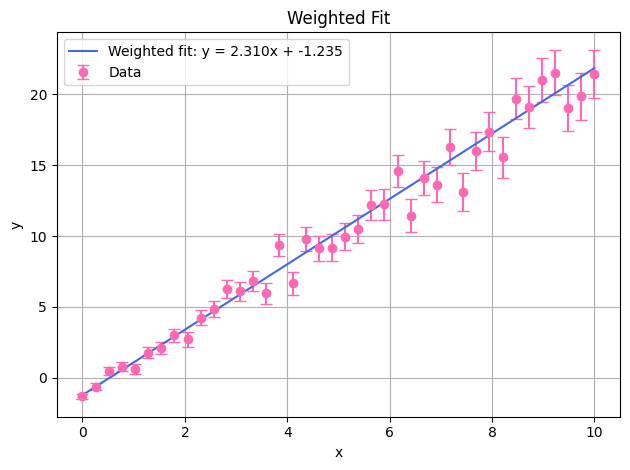

In [20]:
weights = 1 / sigma**2

a_w, b_w = np.polyfit(x, y, 1, w=weights)

y_fit_w = a_w * x_fit + b_w

# Plot
plt.figure()
plt.errorbar(x, y, yerr=sigma, fmt='o', capsize=4, label='Data', color = "hotpink")
plt.plot(x_fit, y_fit_w, label=f'Weighted fit: y = {a_w:.3f}x + {b_w:.3f}', color = "royalblue")
plt.xlabel('x')
plt.ylabel('y')
plt.title('Weighted Fit')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

##### (c) Comparison


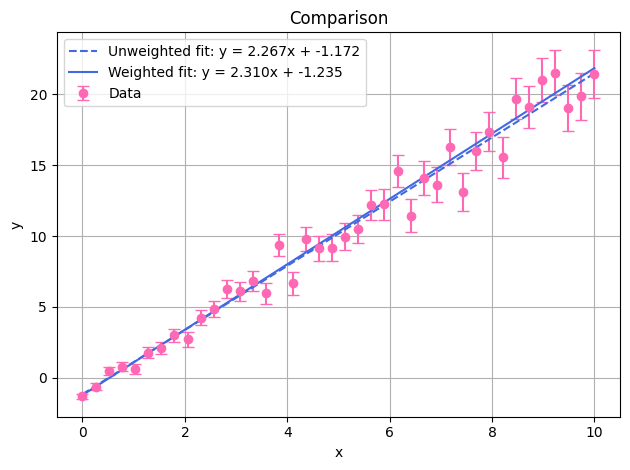

In [19]:
plt.figure()
plt.errorbar(x, y, yerr=sigma, fmt='o', capsize=4, label='Data', color = "hotpink")
plt.plot(x_fit, y_fit, label=f'Unweighted fit: y = {a:.3f}x + {b:.3f}', color = "royalblue", linestyle='--')
plt.plot(x_fit, y_fit_w, label=f'Weighted fit: y = {a_w:.3f}x + {b_w:.3f}', color = "royalblue")
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparison')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

1. Which points influenced the weighted fits more strongly?

The weighted fit is more strongly influenced by points with smaller incertainties/error bars because the weights are $w = 1/\sigma^2$. 

2. Why does inverse-variance weighting improve parameter estimation?

Inverse-variance weighting improves the precision of $a$ and $b$ by assigning higher weight to more precise measurements and lower weight to noisier measurements. This prevents high-uncertainty points from disproportionately influencing the fit. 



##### (d) Conceptual Connection

Suppose instead of fitting a line, you wanted to estimate the amplitude of a known waveform buried in noise with covariance matrix $\Sigma$.
Explain why you would expect the optimal estimator to weight the data by $\Sigma^{-1}$.

When estimating the amplitude of a known waveform buried in noise with covariance matrix $\Sigma$, the optimal estimator weights the data by $\Sigma^{-1}$ because it corresponds to maximizing the Gaussian likelihood and yields the minimum-variance unbiased estimator. The inverse covariance emphasizes directions with lower noise variance while downweighting noisier directions. Instead of weighting each data point by $1/\sigma_i^2$, the entire data vector is weighted by using the inverse covariance matrix, which reduces to inverse-variance weighting when the noise is uncorrelated and correctly handles correlations when it is not. 


#### Problem 3: Matched Filtering, Calibration, and Detection Efficiency

In [42]:
# Helper Functions: 

noise_data = np.load("/Users/laurensdun/phys657-spring2026/Module3/noise_traces.npy")

from problem_3_helper import (
    foldpsd,
    calc_psd,
    optimal_filter_amp,
    fit_spectrum_curvefit
)

##### Part I: Matched Filter Amplitudes

1. Construct a noise power spectal density (PSD), J(f), estimate using the noise-only dataset. Plot the (one-sided) PSD on a log-log plot.

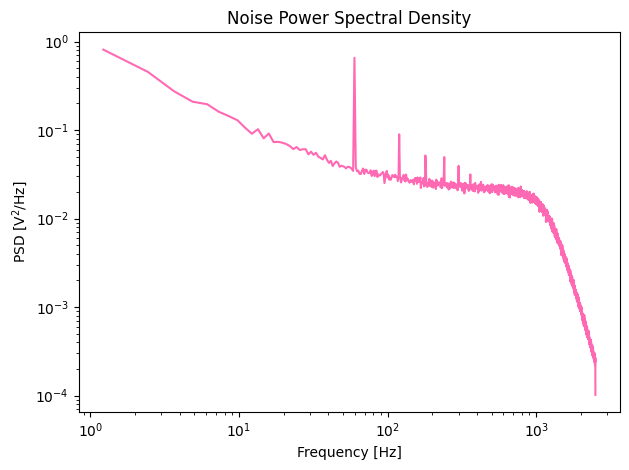

In [50]:
# sampling parameters
fs = 5e3
trace_length = 4096
dt = 1 / fs

# calculate PSD
# calc_psd: Return the PSD of an n-dimensional array, assuming that we want the PSD of the last axis.
f_full, psd_full = calc_psd(noise_data, fs=fs, folded_over=False)

# one-sided PSD for plotting
# foldpsd: Return the one-sided version of the inputted two-sided psd. Supports an n-dimensional array outputted by `calc_psd`.
f_1s, psd_1s = foldpsd(psd_full, fs)

plt.figure()
plt.loglog(f_1s[1:], psd_1s[1:], color = "hotpink")
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [V$^2$/Hz]")
plt.title("Noise Power Spectral Density")
plt.tight_layout()
plt.show()